## ABIDES rmsc03 config simulation analysis

This notebook analyzes the statistical properties of the ABIDES LOB simulation using the `rmsc03` configuration.

The configuration defines a synthetic market environment populated by various autonomous agents, including Noise Agents, Value Agents, Momentum Agents, and an Execution Agent. The following analyses are performed:

- Comparison between the simulated market mid-price and the fundamental value series.
- Correlation analysis between bid–ask spreads and market volatility.
- Visual inspection of returns and rolling volatility over time.
- Analysis of statistical properties of returns (kurtosis, skewness, normality checks) at 1-second and 1-minute aggregations.
- Autocorrelation function (ACF) plots for raw returns and squareed returns.
- Correlation between trading volume and price volatility.
- Volume distribution analysis.
- Price impact curve (Kyle's lambda) analysis.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import seaborn as sns
import os
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# Import data files

LOG_DIR = "../abides_core/log/initial_test_simulation"

files = {
    "exchange": os.path.join(LOG_DIR, "EXCHANGE_AGENT.bz2"),
    "fundamental": os.path.join(LOG_DIR, "fundamental_ABM.bz2"),
    "orderbook": os.path.join(LOG_DIR, "ORDERBOOK_ABM_FULL.bz2"),
    "pov_agent": os.path.join(LOG_DIR, "POV_EXECUTION_AGENT.bz2"),
    "summary": os.path.join(LOG_DIR, "summary_log.bz2")
}

try:
    # Exchange Log of all events 
    df_exchange = pd.read_pickle(files["exchange"])
    print(f"Loaded Exchange Log: {df_exchange.shape[0]} rows")

    # Fundamental Price Log 
    df_fundamental = pd.read_pickle(files["fundamental"])
    print(f"Loaded Fundamental Log: {df_fundamental.shape[0]} rows")

    # Orderbook Log 
    df_orderbook = pd.read_pickle(files["orderbook"])
    print(f"Loaded Orderbook Log: {df_orderbook.shape[0]} rows")

    # POV Agent Log for the Exchange agent (Not useful for analysis here)
    df_pov = pd.read_pickle(files["pov_agent"])
    print(f"Loaded POV Agent Log: {df_pov.shape[0]} rows")

    # Summary Log that contains the end balances and statistics for the agents
    df_summary = pd.read_pickle(files["summary"])
    print(f"Loaded Summary Log: {df_summary.shape[0]} rows")

except Exception as e:
    print(f"\nERROR loading pickles: {e}")

Loaded Exchange Log: 643441 rows
Loaded Fundamental Log: 50126 rows
Loaded Orderbook Log: 65644 rows
Loaded POV Agent Log: 7 rows
Loaded Summary Log: 20484 rows


To get a better idea of how the data is stored we inspect the individual dataframes

In [3]:
print(df_exchange)

                                    EventType          Event
EventTime                                                   
NaT                                AGENT_TYPE  ExchangeAgent
2020-06-03 00:00:00.000002456   WHEN_MKT_OPEN           5027
2020-06-03 00:00:00.000002456  WHEN_MKT_CLOSE           5027
2020-06-03 00:00:00.000002815   WHEN_MKT_OPEN           3885
2020-06-03 00:00:00.000002815  WHEN_MKT_CLOSE           3885
...                                       ...            ...
2020-06-03 11:30:44.213899669    QUERY_SPREAD           5028
2020-06-03 11:30:45.679768003    QUERY_SPREAD           5053
2020-06-03 11:30:46.627679254    QUERY_SPREAD           5005
2020-06-03 11:30:54.050329145    QUERY_SPREAD           1007
2020-06-03 11:30:58.558094639    QUERY_SPREAD           4144

[643441 rows x 2 columns]


In [4]:

print(df_exchange['EventType'].value_counts())

EventType
ORDER_EXECUTED             111998
LIMIT_ORDER                 92966
BEST_ASK                    92961
BEST_BID                    92919
QUERY_SPREAD                67232
ORDER_ACCEPTED              64537
LAST_TRADE                  36770
CANCEL_ORDER                36449
ORDER_CANCELLED             35912
WHEN_MKT_OPEN                5128
WHEN_MKT_CLOSE               5128
QUERY_TRANSACTED_VOLUME      1440
AGENT_TYPE                      1
Name: count, dtype: int64


In [5]:
print(df_exchange[df_exchange['EventType'] == 'ORDER_EXECUTED']["Event"].iloc[0])

{'agent_id': 5078, 'time_placed': '2020-06-03T09:30:00.000009848', 'symbol': 'ABM', 'quantity': 26, 'is_buy_order': 1, 'order_id': 4, 'fill_price': 99793, 'tag': None, 'limit_price': 100042}


In [6]:
print(df_fundamental.head(5))
print(df_fundamental.tail(5))

                               FundamentalValue
FundamentalTime                                
2020-06-03 09:30:00.000000000          100000.0
2020-06-03 09:30:00.000004922          100000.0
2020-06-03 09:30:00.000009848          100000.0
2020-06-03 09:30:00.000186552          100000.0
2020-06-03 09:30:00.000225743          100000.0
                               FundamentalValue
FundamentalTime                                
2020-06-03 11:29:59.664324870           99615.0
2020-06-03 11:29:59.694816912           99615.0
2020-06-03 11:29:59.755752856           99615.0
2020-06-03 11:29:59.874429772           99617.0
2020-06-03 11:29:59.999999999           99619.0


In [7]:
print(df_orderbook.iloc[10000:, 770:790].head(10))

                               99998   99999   100000  100001  100002  100003  \
QuoteTime                                                                       
2020-06-03 09:41:09.891182784       0      -1       0       0       0       0   
2020-06-03 09:41:10.045038568       0      -1       0       0       0       0   
2020-06-03 09:41:10.090623310       0      -1     -45       0       0       0   
2020-06-03 09:41:10.166256125       0      -1     -90       0       0       0   
2020-06-03 09:41:10.331565853       0      -1     -90       0       0       0   
2020-06-03 09:41:10.468642533       0      -1     -90       0       0       0   
2020-06-03 09:41:10.691673125       0      -1     -90       0       0       0   
2020-06-03 09:41:11.007164269       0      -1     -90       0       0       0   
2020-06-03 09:41:11.075878860       0      -1     -90       0       0       0   
2020-06-03 09:41:11.182343771       0      -1     -90       0       0       0   

                           

Here it is clear that the bid volumes have the negative sign.

In [8]:
print(df_pov)

                                         EventType               Event
EventTime                                                             
NaT                                     AGENT_TYPE      ExecutionAgent
NaT                                  STARTING_CASH            10000000
2020-06-03 00:00:00.000000000     HOLDINGS_UPDATED  {'CASH': 10000000}
2020-06-03 11:31:00.000000050       FINAL_HOLDINGS  { CASH: 10000000 }
2020-06-03 11:31:00.000000050  FINAL_CASH_POSITION            10000000
2020-06-03 11:31:00.000000050     MARKED_TO_MARKET            10000000
2020-06-03 11:31:00.000000050          ENDING_CASH            10000000


Statistics for the exchange (start and end balance, which should be equal). Not used in the analysis, but a nice sanity check. 

In [9]:
print(df_summary.iloc[10000:, ].head(10))

       AgentID AgentStrategy            EventType         Event
10000     1625    NoiseAgent  FINAL_CASH_POSITION  1.439388e+07
10001     1625    NoiseAgent          ENDING_CASH  1.000000e+07
10002     1625    NoiseAgent      FINAL_VALUATION  4.393884e-01
10003     1626    NoiseAgent  FINAL_CASH_POSITION  1.598263e+07
10004     1626    NoiseAgent          ENDING_CASH  1.001413e+07
10005     1626    NoiseAgent      FINAL_VALUATION  5.883154e-01
10006     1627    NoiseAgent  FINAL_CASH_POSITION  9.996634e+06
10007     1627    NoiseAgent          ENDING_CASH  9.996634e+06
10008     1627    NoiseAgent      FINAL_VALUATION -3.366000e-04
10009     1628    NoiseAgent  FINAL_CASH_POSITION  4.417276e+06


### Comparison between the simulated market mid-price and the fundamental value series

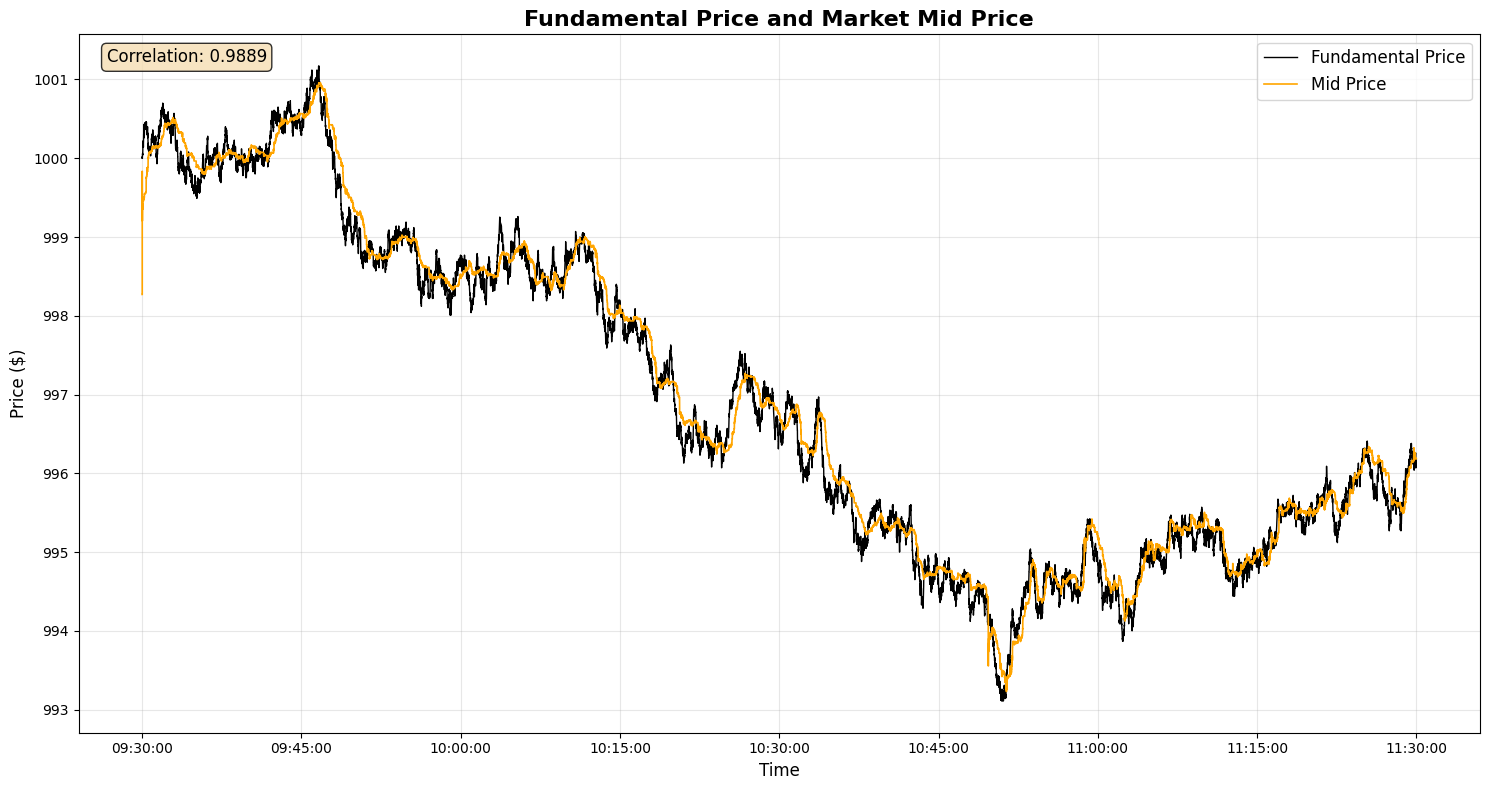

In [10]:
best_bid_prices = []
best_ask_prices = []
mid_prices = []
spreads = []

for timestamp, row in df_orderbook.iterrows():
    bid_levels = row[row<0] # Bids are negative prices in the orderbook dataframe
    best_bid = bid_levels.index.max() if not bid_levels.empty else np.nan

    ask_levels = row[row>0]
    best_ask = ask_levels.index.min() if not ask_levels.empty else np.nan

    if not np.isnan(best_bid) and not np.isnan(best_ask):
        bid_dollar = best_bid / 100.0 # Convert from cents to dollars
        ask_dollar = best_ask / 100.0

        mid_prices.append((bid_dollar + ask_dollar) / 2)
        spreads.append(ask_dollar - bid_dollar)
        best_bid_prices.append(bid_dollar)
        best_ask_prices.append(ask_dollar)

    else:
        mid_prices.append(np.nan)
        spreads.append(np.nan)
        best_bid_prices.append(np.nan)
        best_ask_prices.append(np.nan)

df_prices = pd.DataFrame({
    "best_bid": best_bid_prices,
    "best_ask": best_ask_prices,
    "mid_price": mid_prices,
    "spread": spreads
}, index=df_orderbook.index)

# There are 52 NaN values in the beginning of the series due to no bids/asks 
# in the orderbook. This is irrelevant for the plot so we backfill them
df_prices.bfill()

df_fund_clean = df_fundamental.copy()
df_fund_clean['fundamental_price'] = df_fundamental['FundamentalValue'] / 100.0

start_time = max(df_fund_clean.index.min(), df_prices.index.min())
end_time = min(df_fund_clean.index.max(), df_prices.index.max())

df_aligned = pd.DataFrame({
    'fundamental_price': df_fund_clean.loc[start_time:end_time, 'fundamental_price'],
    'mid_price': df_prices.loc[start_time:end_time, 'mid_price']
})

# There are mismatches in timestamps, we forward fill the missing values
df_aligned.ffill(inplace=True)
df_aligned.bfill(inplace=True)


# Plot 
plt.figure(figsize=(15, 8))

plt.plot(df_aligned.index, df_aligned['fundamental_price'], 
         label='Fundamental Price', color='black', linewidth=1)
plt.plot(df_aligned.index, df_aligned['mid_price'], 
         label='Mid Price', color='orange', linewidth=1.2, alpha=1)

plt.title('Fundamental Price and Market Mid Price', fontsize=16, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

corr_text = f"Correlation: {df_aligned['fundamental_price'].corr(df_aligned['mid_price']):.4f}"
plt.text(0.02, 0.98, corr_text, transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/fundamental_vs_mid_price.png", dpi=300, bbox_inches="tight")
plt.show()


One things pops to mind when inspecting the two time series, that is, that the Mid price lags behind the Fundamental price, which is to be expected in the ABIDES simulator and happens because the Value agents observe the fundamental price with noise to inform their trading. When the Fundamental price moves, they sumbit orders, and the lag we observe could be described as the reaction time of the market. 

In [11]:
# cound the nan values in df_prices 
print(df_prices.isna().sum())

best_bid     52
best_ask     52
mid_price    52
spread       52
dtype: int64


The first 52 values in df_prices are NaN because there was on activity in the order book in the first couple of microseconds of the simulation. We drop these 52 first rows in further analysis

In [12]:
df_prices = df_prices.dropna()

### Correlation analysis between bid–ask spreads and market volatility

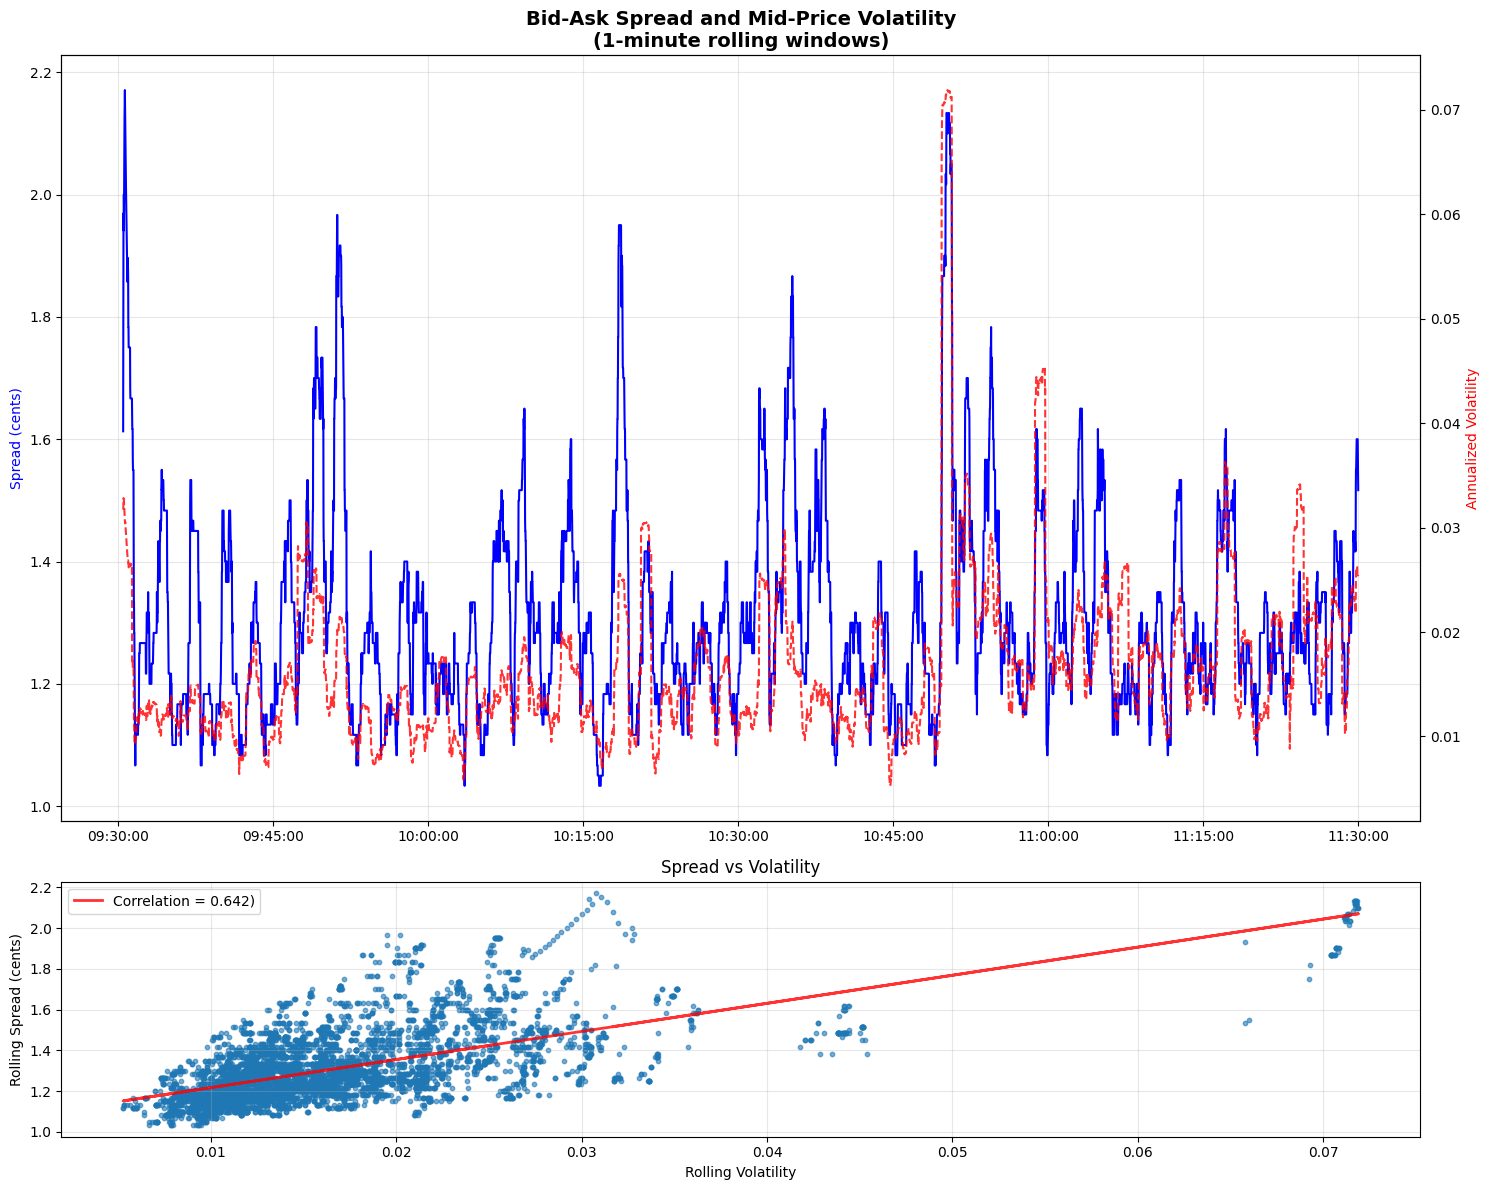

In [13]:

df_prices_resampled = df_prices.resample('1s').last().ffill()

log_returns = np.log(df_prices_resampled["mid_price"]/df_prices_resampled["mid_price"].shift(1))

window = 60
rolling_vol = log_returns.rolling(window=window, min_periods=window//2).std()*np.sqrt(252*60*60)
rolling_spread = df_prices_resampled["spread"].rolling(window=window, min_periods=window//2).mean()
    
df_vol_spread = pd.DataFrame({
    "rolling_volatility": rolling_vol,
    "rolling_spread": rolling_spread
}).dropna() # Due to the min_periods we obtain NaN values in the beginning. 

correlation = df_vol_spread["rolling_volatility"].corr(df_vol_spread["rolling_spread"])

# Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), height_ratios=[3, 1])

# Upper plot of time series
ax1.plot(df_vol_spread.index, df_vol_spread['rolling_spread']*100,  # Scale to cents
         color='blue', label='Avg Spread (1-min)', linewidth=1.5)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_vol_spread.index, df_vol_spread['rolling_volatility'], 
              color='red', linestyle='--', label='Volatility (1-min)', linewidth=1.5, alpha=0.8)
ax1.set_title('Bid-Ask Spread and Mid-Price Volatility\n(1-minute rolling windows)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Spread (cents)', color='blue')
ax1_twin.set_ylabel('Annualized Volatility', color='red')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# Lower scatter plot with correlation
scatter = ax2.scatter(df_vol_spread['rolling_volatility'], df_vol_spread['rolling_spread']*100, # Scale to cents
                    alpha=0.6, s=10)
ax2.set_xlabel('Rolling Volatility')
ax2.set_ylabel('Rolling Spread (cents)')
ax2.grid(True, alpha=0.3)

# # Add correlation text and trend line
z = np.polyfit(df_vol_spread['rolling_volatility'], df_vol_spread['rolling_spread'], 1)
p = np.poly1d(z)
ax2.plot(df_vol_spread['rolling_volatility'], p(df_vol_spread['rolling_volatility']) * 100, 
         "r-", alpha=0.8, lw=2, label=f'Correlation = {correlation:.3f})')

ax2.legend()
ax2.set_title('Spread vs Volatility')

plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/spread_and_volatility.png", dpi=300, bbox_inches="tight")
plt.show()


The analysis shows a correlation of 0.64 between volatility and bid-ask spreads, confirming that market maker agents widen spreads to manage risk during price instability. This validates the simulation's core mechanics. However, with tight spreads of 1–2 cents and low volatility peaking at 7%, the market is very stable. future iterations could improve realism by increasing fundamental volatility to mimic the messier conditions where spoofing could be easier to implement. 

### Visual inspection of returns and rolling volatility over time

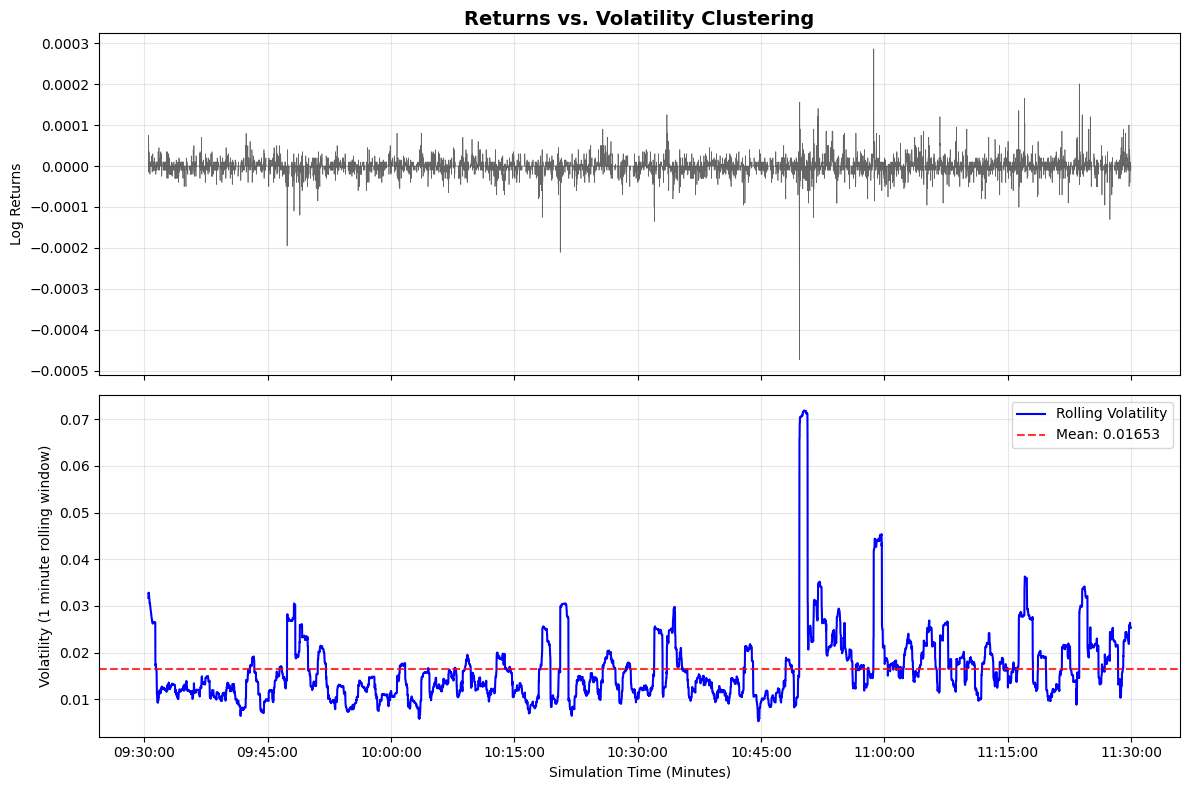

In [14]:
# Create the time axes
df_clustering = pd.DataFrame({
    'log_returns': log_returns,
    'rolling_volatility': df_vol_spread['rolling_volatility']
}).dropna()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Log returns
ax1.plot(df_clustering.index, df_clustering['log_returns'], color='black', alpha=0.6, lw=0.5)
ax1.set_ylabel('Log Returns')
ax1.set_title('Returns vs. Volatility Clustering', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Rolling volatility 
ax2.plot(df_clustering.index, df_clustering['rolling_volatility'], color='blue', lw=1.5, label='Rolling Volatility')
mean_vol = df_clustering['rolling_volatility'].mean()
ax2.axhline(mean_vol, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_vol:.5f}')
ax2.set_ylabel('Volatility (1 minute rolling window)')
ax2.set_xlabel('Simulation Time (Minutes)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/returns_and_volatility_clustering.png", dpi=300, bbox_inches="tight")
plt.show()


The price moves we are looking at are tiny, mostly bouncing within a range of 0.01% (1 basis point). This tells us that the market makers in our simulation have a strong effect. They are absorbing buy and sell orders easily, and the price barely moves. Essentially, we have simulated a very calm, liquid market that (at least visually) doesnt seem to exhibit volatility clustering. While we see one isolated spike in volatility coinciding with a price drop, it dissapears almost immediately. 

### Analysis of statistical properties of returns (kurtosis, skewness, normality checks) at 1-second and 1-minute aggregations

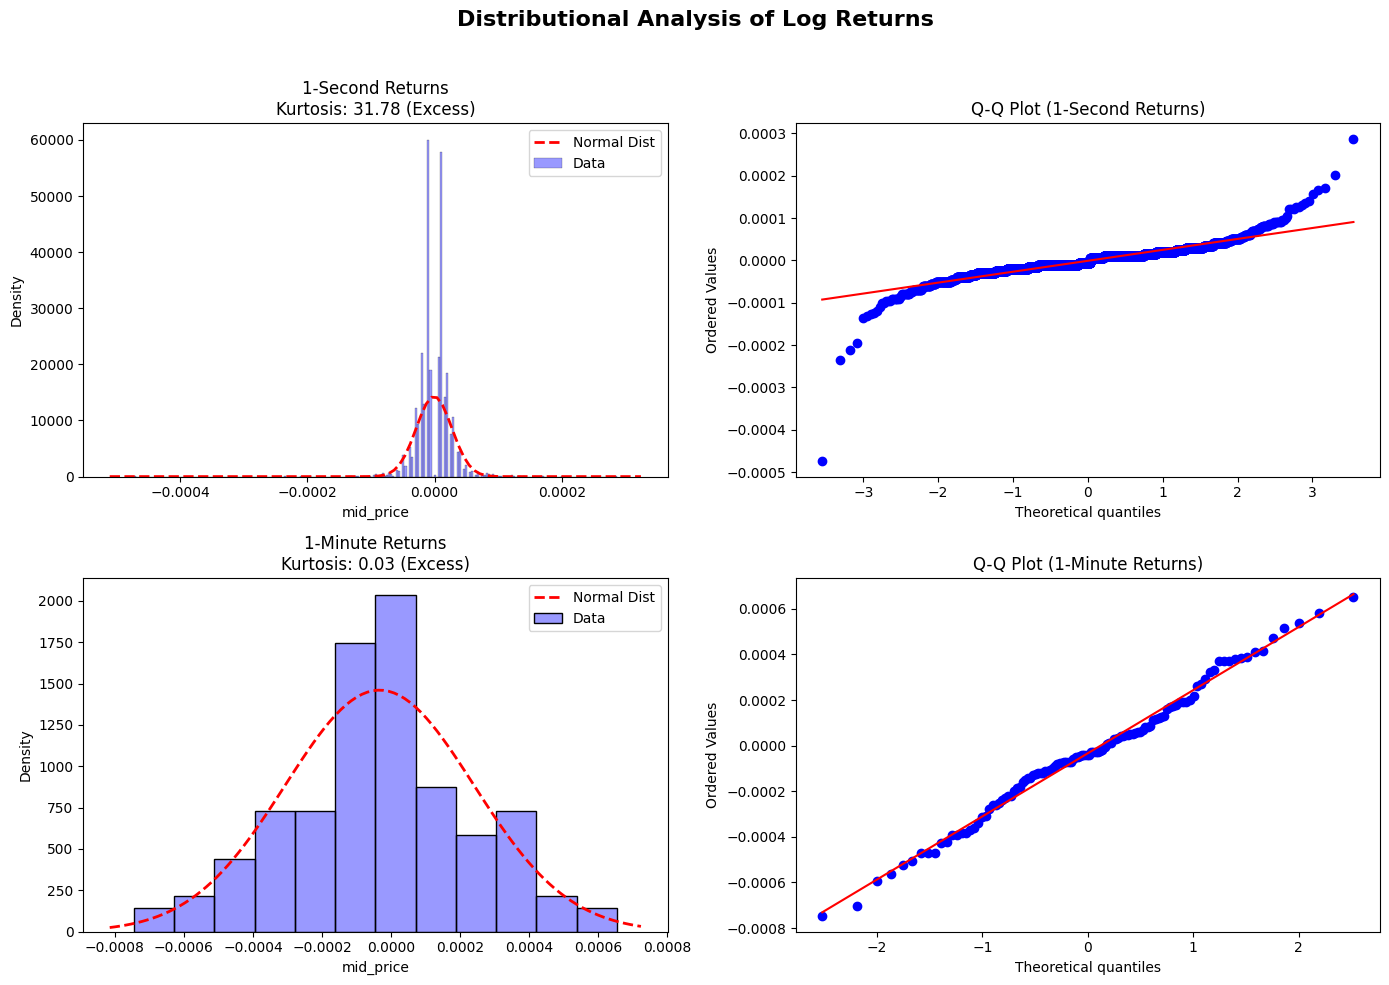

1-Sec Excess Kurtosis: 31.7808
1-Min Excess Kurtosis: 0.0326
1-Sec Skewness: -1.0548
1-Min Skewness: -0.0224


In [15]:
df_prices_resampled_minute = df_prices.resample('1min').last().ffill()
log_returns_minute = np.log(df_prices_resampled_minute["mid_price"]/df_prices_resampled_minute["mid_price"].shift(1))

log_returns_minute = log_returns_minute.dropna()
log_returns = log_returns.dropna() # Drop the first NaN values

log_returns_minute_no_zeros = log_returns_minute[log_returns_minute != 0] # Remove zero returns
log_returns_no_zeros = log_returns[log_returns != 0]

def plot_distribution_check(data, title, ax_hist, ax_qq):
    # Histogram
    sns.histplot(data, kde=False, stat="density", ax=ax_hist, color='blue', alpha=0.4, label='Data')
    
    # Overlay Normal Distribution
    mu, std = stats.norm.fit(data)
    xmin, xmax = ax_hist.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax_hist.plot(x, p, 'r--', linewidth=2, label='Normal Dist')
    ax_hist.set_title(f'{title}\nKurtosis: {stats.kurtosis(data):.2f} (Excess)')
    ax_hist.legend()
    
    # QQ Plot
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'Q-Q Plot ({title})')

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Distributional Analysis of Log Returns', fontsize=16, fontweight='bold')

# 1-Second plots
plot_distribution_check(log_returns_no_zeros, "1-Second Returns", axes[0, 0], axes[0, 1])

# 1-Minute plots
plot_distribution_check(log_returns_minute_no_zeros, "1-Minute Returns", axes[1, 0], axes[1, 1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("rmsc03_analysis_plots/returns_distribution_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Statistics
print(f"1-Sec Excess Kurtosis: {stats.kurtosis(log_returns_no_zeros):.4f}")
print(f"1-Min Excess Kurtosis: {stats.kurtosis(log_returns_minute_no_zeros):.4f}")
print(f"1-Sec Skewness: {stats.skew(log_returns_no_zeros):.4f}")
print(f"1-Min Skewness: {stats.skew(log_returns_minute_no_zeros):.4f}")

The results show a pattern known as "Aggregational Gaussianity." At the 1-second level, the returns are definitely not normal. The massive Kurtosis of 31.78 and the S-shaped Q-Q plot confirm that the market is dominated by small noise and occasional sharp jumps (heavy tails). The negative skew also suggests that the biggest jumps are price drops.

But when we zoom out to 1-minute intervals, the central limit theorem starts to take effect. The Kurtosis drops to near zero (0.03), and the Q-Q plot becomes an almost straight line, meaning the returns have become more Gaussian. 

This result alligns very well with real market data. 

### Autocorrelation function (ACF) plots for log returns and squared log returns.

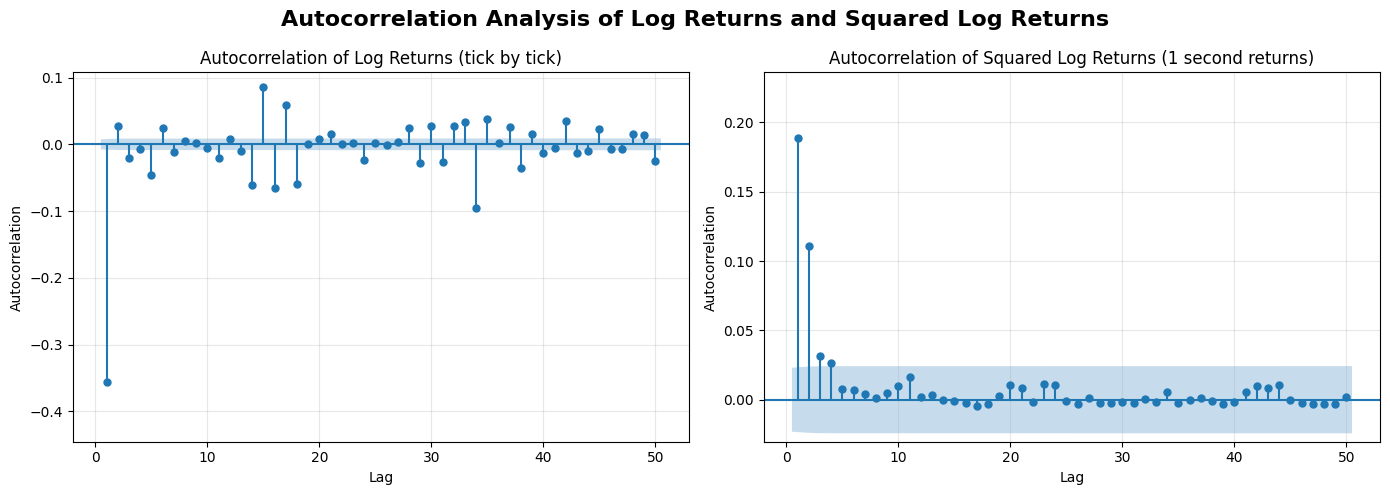

In [16]:
tick_log_returns = np.log(df_prices['mid_price'] / df_prices['mid_price'].shift(1)).dropna()
log_returns_squared = log_returns ** 2

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autocorrelation Analysis of Log Returns and Squared Log Returns', fontsize=16, fontweight='bold')

# Plot log return lags
plot_acf(tick_log_returns, lags=50, ax=ax1, title='Autocorrelation of Log Returns (tick by tick)', zero=False, auto_ylims=True)
ax1.set_xlabel('Lag')
ax1.set_ylabel('Autocorrelation')
ax1.grid(True, alpha=0.3)

# Plot squared log return lags
plot_acf(log_returns_squared, lags=50, ax=ax2, title='Autocorrelation of Squared Log Returns (1 second returns)', zero=False, auto_ylims=True)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelation')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/log_returns_autocorrelation_analysis.png", dpi=300, bbox_inches="tight")
plt.show()


Analyzing the returns on a tick-by-tick basis shows a Lag-1 correlation of -0.3. This negative correlation is reffered to as the "Bid-Ask Bounce," a well-known phenomenon in high-frequency markets. Essentially, this means that if the price ticks up (a buy order hits the ask), the very next price move is statistically likely to be down (a sell order hitting the bid). This confirms that our market simulation is Mean Reverting at the micro-scale.

There is a clear memory of risk at Lag 1 (0.20) and Lag 2 (0.10), but it collapses to zero immediately after. The occasional negative values suggests that volatility doesn't just fade; it is actively reverted by the market making agents. This confirms the visual inspection of volatility that we did above. Shocks are absorbed so quickly that volatility clustering cannot sustain itself beyond a mere two seconds."

### Correlation between trading volume and return volatility

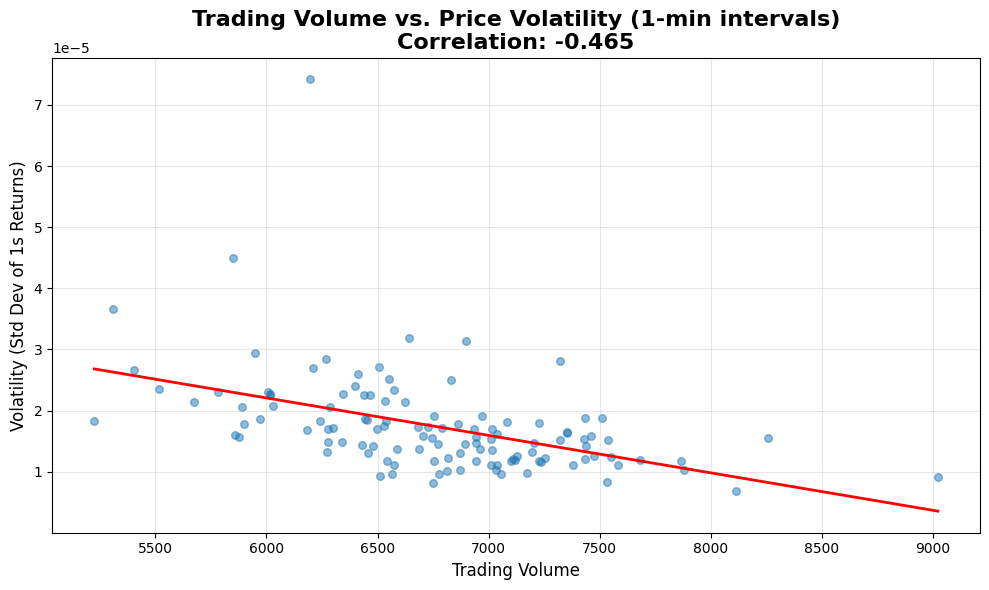

In [17]:
executed_orders = df_exchange[df_exchange['EventType'] == 'ORDER_EXECUTED'].copy()
executed_orders['volume'] = executed_orders['Event'].apply(lambda x: x['quantity'])
volume_1min = executed_orders['volume'].resample('1min').sum() / 2 # Divide by 2 because of double counting buy/sell sides

volatility_1min = log_returns.resample('1min').std()

df_vol_volume = pd.DataFrame({
    'volume': volume_1min,
    'volatility': volatility_1min
})

df_vol_volume = df_vol_volume.iloc[1:] # Drop first minute becasue at the beginning of the simulation the LOB is empty

corr = df_vol_volume['volume'].corr(df_vol_volume['volatility'])

# Plot 
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(x='volume', y='volatility', data=df_vol_volume, 
            scatter_kws={'alpha': 0.5, 's': 30}, 
            line_kws={'color': 'red', 'linewidth': 2},
            ci=None,
            ax=ax)

ax.set_title(f'Trading Volume vs. Price Volatility (1-min intervals)\nCorrelation: {corr:.3f}', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Trading Volume', fontsize=12)
ax.set_ylabel('Volatility (Std Dev of 1s Returns)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/volume_vs_volatility.png", dpi=300, bbox_inches="tight")
plt.show()


The negative correlation is the opposite to empirical observations in market data where volume and volatility are positively correlated. In our simulation, when agents trade a lot, they aren't pushing the price aournd much. In this market simulation activity creates stability in prices. 

### Volume distribution analysis

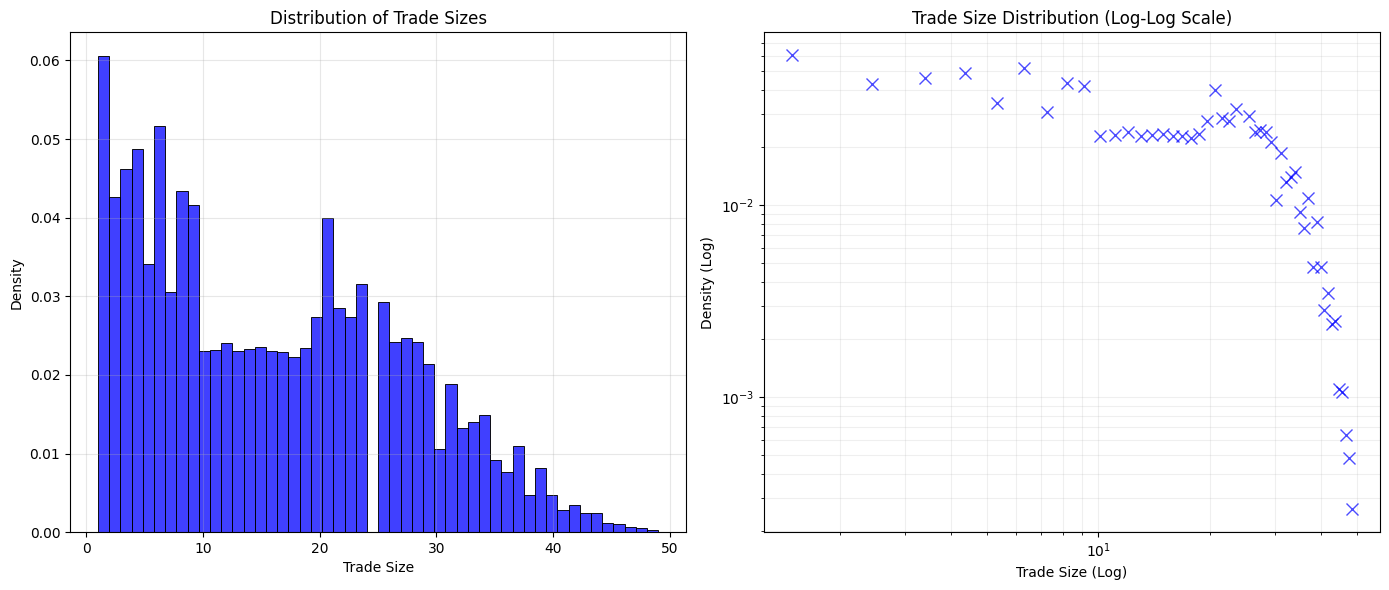

Skewness: 0.4338
Kurtosis: -0.8011


In [18]:

volumes = executed_orders['volume']

# Plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogram 
sns.histplot(volumes, bins=50, kde=False, ax=ax1, color='blue', stat='density')
ax1.set_title('Distribution of Trade Sizes')
ax1.set_xlabel('Trade Size')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)

# Log-Log Plot
counts, bin_edges = np.histogram(volumes, bins=50, density=True)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mask = counts > 0 # Remove zero counts for log scaling
centers = centers[mask]
counts = counts[mask]

ax2.loglog(centers, counts, 'bx', markersize=8, alpha=0.7)
ax2.set_title('Trade Size Distribution (Log-Log Scale)')
ax2.set_xlabel('Trade Size (Log)')
ax2.set_ylabel('Density (Log)')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/trade_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Skewness and Kurtosis
print(f"Skewness: {volumes.skew():.4f}")
print(f"Kurtosis: {volumes.kurtosis():.4f}")

The volume distribution analysis shows what we would expect given the simulation design. The histogram shows a gradual decline from small trades to larger ones up to 50, and the log-log plot confirms a bounded uniform distribution. The points plateau horizontally before abruptly dropping off at the maximum trade size. This is the result of the noise agents drawing order sizes from a Uniform(1, 50) distribution rather than exhibiting the heavy tailed behavior seen in real markets where very large trades create rare but massive spikes.

### Price impact curve analysis

In [19]:
executed_orders['side'] = executed_orders['Event'].apply(lambda x: x['is_buy_order'])
executed_orders['signed_volume'] = executed_orders.apply(lambda row: row['volume'] if row['side'] else -row['volume'], axis=1)
executed_orders["time_placed"] = pd.to_datetime(executed_orders['Event'].apply(lambda x: x['time_placed']))
executed_orders["agent_id"] = executed_orders['Event'].apply(lambda x: x['agent_id'])

print(executed_orders["time_placed"])


EventTime
2020-06-03 09:30:00.000014788   2020-06-03 09:30:00.000009848
2020-06-03 09:30:00.000014788   2020-06-03 09:30:00.000004922
2020-06-03 09:30:00.000023509   2020-06-03 09:30:00.000015679
2020-06-03 09:30:00.000023509   2020-06-03 09:30:00.000004922
2020-06-03 09:30:00.000078369   2020-06-03 09:30:00.000052245
                                             ...             
2020-06-03 11:29:59.538421070   2020-06-03 11:29:58.752537640
2020-06-03 11:29:59.757951766   2020-06-03 11:29:59.755752856
2020-06-03 11:29:59.757951766   2020-06-03 11:29:58.752537640
2020-06-03 11:29:59.757951766   2020-06-03 11:29:59.755752856
2020-06-03 11:29:59.757951766   2020-06-03 11:29:59.484786090
Name: time_placed, Length: 111998, dtype: datetime64[ns]


Here an important assumption is made. For the ORDER_EXECUTED event type, both sides of the order are recorded. This means that the net volume will always sum to zero and we always have pairs of order executions (Check EventTime index). The event information logs the time at which the orders were placed, and we assume that the aggressor (the one wanting to trade) places the order at a later point in time. To then obtain the actual net volume at a given point in time, we have to consider only the orders that were placed later (between each individual pair).

There are alse cases like the one in the bottom where tehre are more than 2 rows with the same EvetTime. Inspecting those showed that is was one order (the latest one) matching against multiple other resting orders, so the logic for getting the aggressing order is the same as with a pair of matched orders.  

In [20]:
def taker_signed_volume(group):
    tp_max = group["time_placed"].max()
    taker_rows = group[group["time_placed"] == tp_max]
    return taker_rows["signed_volume"].sum()

taker_flow = executed_orders.groupby(executed_orders.index).apply(taker_signed_volume)

net_volume_minute = taker_flow.resample('1min').sum()
net_volume_minute.name = 'net_volume'

net_volume_minute = net_volume_minute.iloc[1:] # Drop first minute since log_returns_minute has a NaN value

df_impact = pd.concat([log_returns_minute, net_volume_minute], axis=1)

X = df_impact['net_volume']
Y = df_impact['mid_price'] #TODO: Have to change the name to log_returns when creating the series

# Note: Standard Kyle's theory assumes no intercept (C=0), 
# but we usually add a constant to check for drift.
X_with_const = sm.add_constant(X)

model = sm.OLS(Y, X_with_const).fit()
lambda_kyle = model.params['net_volume']
r_squared = model.rsquared

print(f"Kyle's Lambda (Price Impact): {lambda_kyle:.2e}")
print(model.summary())

Kyle's Lambda (Price Impact): 2.66e-07
                            OLS Regression Results                            
Dep. Variable:              mid_price   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     128.1
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           1.65e-20
Time:                        12:29:10   Log-Likelihood:                 852.08
No. Observations:                 119   AIC:                            -1700.
Df Residuals:                     117   BIC:                            -1695.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1

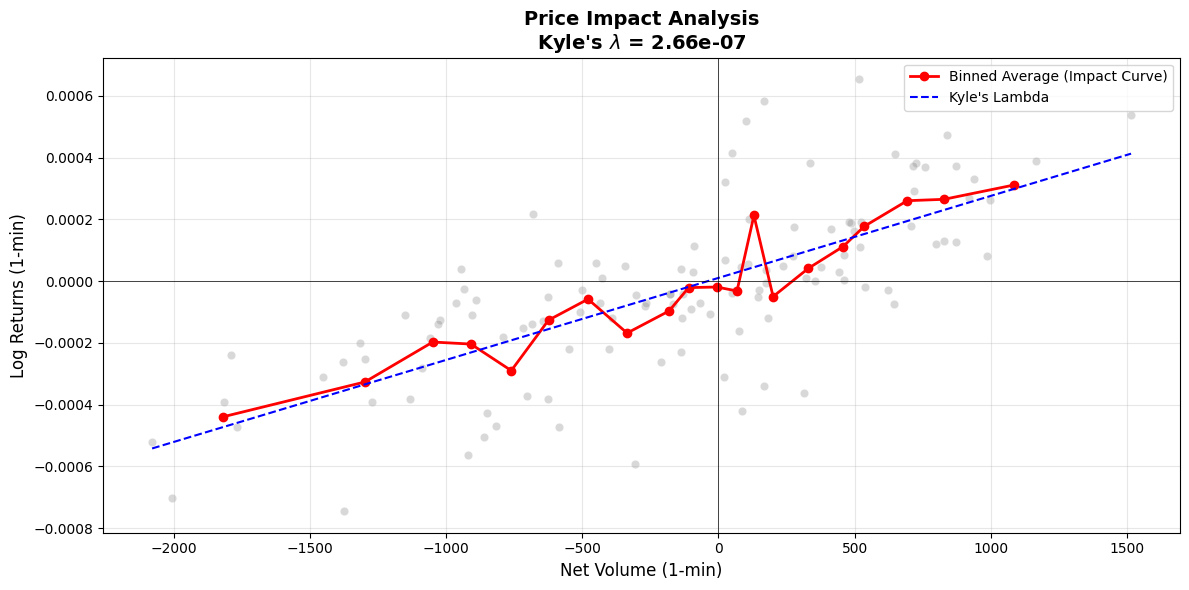

In [21]:
# Plot 
plt.figure(figsize=(12, 6))

# Scatter plot
sns.scatterplot(
    data=df_impact, 
    x='net_volume', 
    y='mid_price', 
    alpha=0.3, 
    color='gray', 
)

# Average Binned Impact Curve
df_impact['VolumeBin'] = pd.qcut(df_impact['net_volume'], q=20, duplicates='drop') # Divide net volume into 20 quantiles
binned_data = df_impact.groupby('VolumeBin', observed=True)[['net_volume', 'mid_price']].mean()
plt.plot(
    binned_data['net_volume'], 
    binned_data['mid_price'], 
    color='red', 
    marker='o', 
    linewidth=2, 
    label='Binned Average (Impact Curve)'
)

# Regression (Kyle's Lambda)
x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.params['const'] + lambda_kyle * x_range
plt.plot(x_range, y_pred, color='blue', linestyle='--', label=f"Kyle's Lambda")

plt.title(f'Price Impact Analysis\nKyle\'s $\lambda$ = {lambda_kyle:.2e}', fontsize=14, fontweight='bold')
plt.xlabel('Net Volume (1-min)', fontsize=12)
plt.ylabel('Log Returns (1-min)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("rmsc03_analysis_plots/price_impact_analysis.png", dpi=300, bbox_inches="tight")
plt.show()


The price impact analysis aligns with theoretical expectations for an efficient market. Net volume and log returns exhibit a strong positive correlation ($R^2 \approx 0.52$). The regression coefficient (Kyle's Lambda) is veru low ($\lambda = 2.66 \times 10^{-7}$). The analysis implies a linear price impact where a trader must execute a net volume of approximately 376 units (x * $\lambda$ = 0.0001, x = 376) to shift the price by one basis point. This aligns with the other results that the market is very liquid, with Market Makers absorbing order flow imbalances and preventiing significant price volatility without any sustained one sided pressure, that would come from the value agents.